In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
from models.bsm import BlackScholesModel

In [2]:
nifty_50_data = pd.read_csv('data/nifty_50_historical_data.csv', parse_dates=['Date'], index_col='Date')
nifty_50_data.sort_index(inplace=True)
nifty_50_data.dropna(inplace=True)
nifty_50_data


,Close,Open,High,Low,logReturn,pctReturn
Date,,,,,,
2024-11-12,23883.45,24225.80,24242.00,23839.15,-0.010738,-0.010681
2024-11-13,23559.05,23822.45,23873.60,23509.60,-0.013676,-0.013583
2024-11-14,23532.70,23542.15,23675.90,23484.15,-0.001119,-0.001118
2024-11-18,23453.80,23605.30,23606.80,23350.40,-0.003358,-0.003353
2024-11-19,23518.50,23529.55,23780.65,23464.80,0.002755,0.002759
...,...,...,...,...,...,...
2025-12-10,25758.00,25864.05,25947.65,25734.55,-0.003165,-0.003160
2025-12-11,25898.55,25771.40,25922.80,25693.25,0.005442,0.005457
2025-12-12,26046.95,25971.20,26057.60,25938.45,0.005714,0.005730


In [3]:
print(f"Mean Return: {nifty_50_data['logReturn'].mean()}\n\
Std Dev of Return: {nifty_50_data['logReturn'].std()}\n\
Annualized Return: {(1+nifty_50_data['logReturn'].mean())**252-1}\n\
Annualized Std Dev: {nifty_50_data['logReturn'].std()*np.sqrt(252)}")

Mean Return: 0.0002528572557571448
Std Dev of Return: 0.007663757733111906
Annualized Return: 0.06578538040684223
Annualized Std Dev: 0.12165838242037331


<Axes: title={'center': 'Nifty 50 Log Returns Over Time'}, xlabel='Date'>

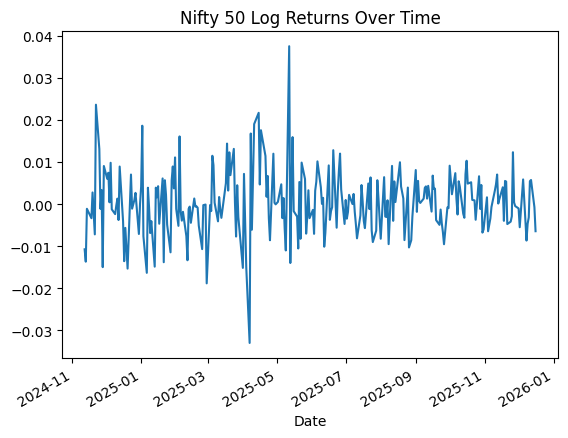

In [4]:
nifty_50_data['logReturn'].plot(title='Nifty 50 Log Returns Over Time')

<Axes: title={'center': '30-Day Rolling Annualized Volatility of Nifty 50'}, xlabel='Date'>

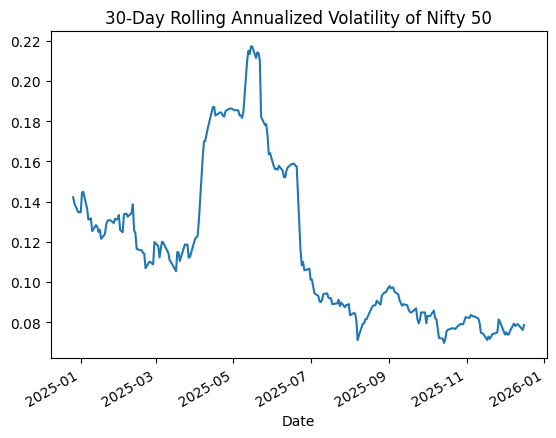

In [5]:
nifty_50_data['sigma30'] = nifty_50_data['logReturn'].rolling(window=30).std()*np.sqrt(252)
nifty_50_data['sigma30'].plot(title='30-Day Rolling Annualized Volatility of Nifty 50')

In [6]:
option_data = pd.read_csv('data/nifty_50_options_chain.csv', parse_dates=['Date', 'Expiry Date'], index_col='Date')
option_data.sort_index(inplace=True)
option_data.dropna(inplace=True)
option_data

,Expiry Date,Option Type,Strike Price,Open Price,High Price,Low Price,Close Price,Last Price,Settlement Price,Volume,Value (₹ Lakhs),Premium Value (₹ Lakhs),Open Interest,Change in OI
Date,,,,,,,,,,,,,,
2025-11-12,2025-12-16,PE,"26,500.00",562.10,564.00,530.10,533.05,533.05,678.30,900,"2,43,42,540.00","4,92,540.00",450,450
2025-11-12,2025-12-16,CE,"25,900.00",431.00,473.65,407.60,468.90,468.90,445.75,3225,"8,49,13,192.50","13,85,692.50",1650,1650
2025-11-12,2025-12-16,CE,"27,450.00",51.00,51.00,13.00,21.00,20.00,21.00,1575,"4,32,69,191.25","35,441.25",675,675
2025-11-12,2025-12-16,CE,"26,200.00",252.05,303.20,252.05,286.75,286.75,286.75,1125,"2,97,94,035.00","3,19,035.00",750,750
2025-11-12,2025-12-16,CE,"25,800.00",488.00,541.65,468.90,505.50,504.80,505.50,3150,"8,28,46,500.00","15,76,500.00",975,975
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-16,2025-12-16,PE,"24,850.00",0.95,1.00,0.05,0.10,0.05,"25,860.10",6546225,"1,62,67,71,36,168.75","34,44,918.75",565050,-216975
2025-12-16,2025-12-16,CE,"24,550.00","1,352.00","1,356.00","1,342.00","1,342.00","1,342.00","25,860.10",1275,"3,30,22,950.00","17,21,700.00",225,-1050
2025-12-16,2025-12-16,PE,"24,250.00",0.75,0.80,0.05,0.10,0.05,"25,860.10",1963650,"47,61,93,10,635.00","7,98,135.00",158625,-82650


In [7]:
sigma = [nifty_50_data['sigma30'][date] for date in option_data.index]
r = [0.1]*len(option_data) #nse mentions 10% used to calc impl vol
S0 = pd.Series(nifty_50_data['Close'][date] for date in option_data.index)
K = option_data['Strike Price'].str.replace(",", "")
T = option_data['Expiry Date']-option_data.index
T = T.dt.days
bsm_prices_df = pd.DataFrame({'Date': list(option_data.index), \
                              'Type': list(option_data['Option Type']), \
                              'S0': list(S0), 'K': list(K), \
                                'T': list(T), 'sigma': list(sigma), \
                                'r': list(r), \
                                'Close Price': list(option_data['Close Price']), \
                                'LTP': list(option_data['Last Price'])})

In [8]:
bsm_prices_df['Date'] = pd.to_datetime(bsm_prices_df['Date'])
bsm_prices_df['S0'] = bsm_prices_df['S0'].astype(float)
bsm_prices_df['K'] = bsm_prices_df['K'].astype(float)
bsm_prices_df['T'] = bsm_prices_df['T'].astype(float)
bsm_prices_df['sigma'] = bsm_prices_df['sigma'].astype(float)
bsm_prices_df['r'] = bsm_prices_df['r'].astype(float)
bsm_prices_df['Close Price'] = bsm_prices_df['Close Price'].str.replace(',', '').astype(float)
bsm_prices_df['LTP'] = bsm_prices_df['LTP'].str.replace(',', '').astype(float)
bsm_prices_df

,Date,Type,S0,K,T,sigma,r,Close Price,LTP
0,2025-11-12,PE,25875.8,26500.0,34.0,0.074745,0.1,533.05,533.05
1,2025-11-12,CE,25875.8,25900.0,34.0,0.074745,0.1,468.90,468.90
2,2025-11-12,CE,25875.8,27450.0,34.0,0.074745,0.1,21.00,20.00
3,2025-11-12,CE,25875.8,26200.0,34.0,0.074745,0.1,286.75,286.75
4,2025-11-12,CE,25875.8,25800.0,34.0,0.074745,0.1,505.50,504.80
...,...,...,...,...,...,...,...,...,...
2754,2025-12-16,PE,25860.1,24850.0,0.0,0.078564,0.1,0.10,0.05
2755,2025-12-16,CE,25860.1,24550.0,0.0,0.078564,0.1,1342.00,1342.00
2756,2025-12-16,PE,25860.1,24250.0,0.0,0.078564,0.1,0.10,0.05
2757,2025-12-16,CE,25860.1,25400.0,0.0,0.078564,0.1,471.05,460.50


In [9]:
bsm_model = BlackScholesModel()
bsm_prices_df['BSM Price'] = [bsm_model.price_options(S0=row['S0'], \
                            K=row['K'], T=row['T']/252, r=row['r'],\
                            sigma=row['sigma'], option_type=row['Type']) for index, row in bsm_prices_df.iterrows()]

In [10]:
bsm_prices_df['BSM Price'] = bsm_prices_df['BSM Price'].round(2)
bsm_prices_df['Error vs Close'] = (bsm_prices_df['BSM Price'] - bsm_prices_df['Close Price']).round(2)
bsm_prices_df['Error vs LTP'] = (bsm_prices_df['BSM Price'] - bsm_prices_df['LTP']).round(2)
bsm_prices_df['Percent Error vs Close'] = ((bsm_prices_df['Error vs Close'] / bsm_prices_df['Close Price'])*100).round(5)
bsm_prices_df['Percent Error vs LTP'] = ((bsm_prices_df['Error vs LTP'] / bsm_prices_df['LTP'])*100).round(5)
bsm_prices_df

,Date,Type,S0,K,T,sigma,r,Close Price,LTP,BSM Price,Error vs Close,Error vs LTP,Percent Error vs Close,Percent Error vs LTP
0,2025-11-12,PE,25875.8,26500.0,34.0,0.074745,0.1,533.05,533.05,439.40,-93.65,-93.65,-17.56871,-17.56871
1,2025-11-12,CE,25875.8,25900.0,34.0,0.074745,0.1,468.90,468.90,472.04,3.14,3.14,0.66965,0.66965
2,2025-11-12,CE,25875.8,27450.0,34.0,0.074745,0.1,21.00,20.00,14.65,-6.35,-5.35,-30.23810,-26.75000
3,2025-11-12,CE,25875.8,26200.0,34.0,0.074745,0.1,286.75,286.75,296.92,10.17,10.17,3.54664,3.54664
4,2025-11-12,CE,25875.8,25800.0,34.0,0.074745,0.1,505.50,504.80,540.73,35.23,35.93,6.96934,7.11767
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2754,2025-12-16,PE,25860.1,24850.0,0.0,0.078564,0.1,0.10,0.05,0.00,-0.10,-0.05,-100.00000,-100.00000
2755,2025-12-16,CE,25860.1,24550.0,0.0,0.078564,0.1,1342.00,1342.00,1310.35,-31.65,-31.65,-2.35842,-2.35842
2756,2025-12-16,PE,25860.1,24250.0,0.0,0.078564,0.1,0.10,0.05,0.00,-0.10,-0.05,-100.00000,-100.00000
2757,2025-12-16,CE,25860.1,25400.0,0.0,0.078564,0.1,471.05,460.50,460.35,-10.70,-0.15,-2.27152,-0.03257


In [11]:
bsm_prices_df['Implied Volatility'] = [bsm_model.implied_volatility(market_price=row['LTP'], \
                                        S0=row['S0'], K=row['K'], T=row['T']/252, \
                                        r=row['r'], option_type=row['Type']) for index, row in bsm_prices_df.iterrows()]
bsm_prices_df['Implied Volatility'] = bsm_prices_df['Implied Volatility'].round(5)
bsm_prices_df

Newton's method failed: Tolerance of -0.0004980847114258924 reached. Failed to converge after 10 iterations, value is 0.006613036214523871.
Brent's method failed: f(a) and f(b) must have different signs
Newton's method failed: Tolerance of -488212065189.8527 reached. Failed to converge after 8 iterations, value is 12848343883.694996.
Brent's method failed: f(a) and f(b) must have different signs
Newton's method failed: Tolerance of 15657.096846822269 reached. Failed to converge after 7 iterations, value is -72.7881815803242.
Brent's method failed: f(a) and f(b) must have different signs
Newton's method failed: Tolerance of 528.6916288451321 reached. Failed to converge after 39 iterations, value is -485.55740777607156.
Brent's method failed: f(a) and f(b) must have different signs
Newton's method failed: Tolerance of 30048033.411665574 reached. Failed to converge after 8 iterations, value is -49087.896006365874.
Brent's method failed: f(a) and f(b) must have different signs
Newton's met

,Date,Type,S0,K,T,sigma,r,Close Price,LTP,BSM Price,Error vs Close,Error vs LTP,Percent Error vs Close,Percent Error vs LTP,Implied Volatility
0,2025-11-12,PE,25875.8,26500.0,34.0,0.074745,0.1,533.05,533.05,439.40,-93.65,-93.65,-17.56871,-17.56871,0.10065
1,2025-11-12,CE,25875.8,25900.0,34.0,0.074745,0.1,468.90,468.90,472.04,3.14,3.14,0.66965,0.66965,0.07382
2,2025-11-12,CE,25875.8,27450.0,34.0,0.074745,0.1,21.00,20.00,14.65,-6.35,-5.35,-30.23810,-26.75000,0.07975
3,2025-11-12,CE,25875.8,26200.0,34.0,0.074745,0.1,286.75,286.75,296.92,10.17,10.17,3.54664,3.54664,0.07206
4,2025-11-12,CE,25875.8,25800.0,34.0,0.074745,0.1,505.50,504.80,540.73,35.23,35.93,6.96934,7.11767,0.06293
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2754,2025-12-16,PE,25860.1,24850.0,0.0,0.078564,0.1,0.10,0.05,0.00,-0.10,-0.05,-100.00000,-100.00000,1.23049
2755,2025-12-16,CE,25860.1,24550.0,0.0,0.078564,0.1,1342.00,1342.00,1310.35,-31.65,-31.65,-2.35842,-2.35842,3.64242
2756,2025-12-16,PE,25860.1,24250.0,0.0,0.078564,0.1,0.10,0.05,0.00,-0.10,-0.05,-100.00000,-100.00000,1.91779
2757,2025-12-16,CE,25860.1,25400.0,0.0,0.078564,0.1,471.05,460.50,460.35,-10.70,-0.15,-2.27152,-0.03257,0.65120


In [12]:
bsm_prices_df['Implied Volatility'].count()/len(bsm_prices_df)

np.float64(0.831823124320406)

In [13]:
bsm_prices_df['Delta'] = [bsm_model.calculate_delta(S0=row['S0'], \
                            K=row['K'], T=row['T']/252, r=row['r'],\
                            sigma=row['sigma'], option_type=row['Type']) for index, row in bsm_prices_df.iterrows()]
bsm_prices_df['Gamma'] = [bsm_model.calculate_gamma(S0=row['S0'], \
                            K=row['K'], T=row['T']/252, r=row['r'],\
                            sigma=row['sigma'], option_type=row['Type']) for index, row in bsm_prices_df.iterrows()]
bsm_prices_df['Vega'] = [bsm_model.calculate_vega(S0=row['S0'], \
                            K=row['K'], T=row['T']/252, r=row['r'],\
                            sigma=row['sigma'], option_type=row['Type']) for index, row in bsm_prices_df.iterrows()]
bsm_prices_df['Rho'] = [bsm_model.calculate_rho(S0=row['S0'], \
                            K=row['K'], T=row['T']/252, r=row['r'],\
                            sigma=row['sigma'], option_type=row['Type']) for index, row in bsm_prices_df.iterrows()]
bsm_prices_df['Theta'] = [bsm_model.calculate_theta(S0=row['S0'], \
                            K=row['K'], T=row['T']/252, r=row['r'],\
                            sigma=row['sigma'], option_type=row['Type']) for index, row in bsm_prices_df.iterrows()]


In [14]:
Q1 = bsm_prices_df['Percent Error vs Close'].quantile(0.25)
Q3 = bsm_prices_df['Percent Error vs Close'].quantile(0.75)
IQR = Q3 - Q1
bsm_prices_df = bsm_prices_df[(bsm_prices_df['Percent Error vs Close'] >= Q1 - 1.5 * IQR) & (bsm_prices_df['Percent Error vs Close'] <= Q3 + 1.5 * IQR)]

In [15]:
print("Mean Error vs Close Price:", bsm_prices_df['Error vs Close'].mean())
print("Mean Error vs LTP:", bsm_prices_df['Error vs LTP'].mean())
print("Mean Percent Error vs Close Price:", bsm_prices_df['Percent Error vs Close'].mean())
print("Mean Percent Error vs LTP:", bsm_prices_df['Percent Error vs LTP'].mean())
print("Std Dev of Percent Error vs Close Price:", bsm_prices_df['Percent Error vs Close'].std())
print("Std Dev of Percent Error vs LTP:", bsm_prices_df['Percent Error vs LTP'].std())

Mean Error vs Close Price: -7.764297130403197
Mean Error vs LTP: -7.334420632037778
Mean Percent Error vs Close Price: -32.390023788594256
Mean Percent Error vs LTP: -31.98444552851435
Std Dev of Percent Error vs Close Price: 45.28771555826485
Std Dev of Percent Error vs LTP: 45.855095949895926


In [16]:
fig = px.scatter(bsm_prices_df, x='Close Price', y='BSM Price', title='BSM Model Prices vs Actual Close Prices')
fig.add_shape(type='line', x0=0, y0=0, x1=bsm_prices_df['Close Price'].max(), y1=bsm_prices_df['Close Price'].max(),
              line=dict(color='Red',), xref='x', yref='y')
fig.show()


In [17]:
fig = px.scatter(bsm_prices_df, x='LTP', y='BSM Price', title='BSM Model Prices vs Actual Last Prices')
fig.add_shape(type='line', x0=0, y0=0, x1=bsm_prices_df['Close Price'].max(), y1=bsm_prices_df['Close Price'].max(),
              line=dict(color='Red',), xref='x', yref='y')
fig.show()

In [18]:
fig = px.scatter(bsm_prices_df.iloc[np.where(bsm_prices_df['Close Price']<=500)[0]], x='Close Price', y='BSM Price', title='BSM Model Prices vs Actual Close Prices')
fig.add_shape(type='line', x0=0, y0=0, x1=500, y1=500,
              line=dict(color='Red',), xref='x', yref='y')
fig.show()

In [19]:
fig = px.scatter(bsm_prices_df.iloc[np.where(bsm_prices_df['LTP']<=500)[0]], x='LTP', y='BSM Price', title='BSM Model Prices vs Actual Last Prices')
fig.add_shape(type='line', x0=0, y0=0, x1=500, y1=500,
              line=dict(color='Red',), xref='x', yref='y')
fig.show()

In [20]:
fig = px.scatter(bsm_prices_df, x='Close Price', y='Percent Error vs Close', title='Percent Error vs Close Price')
fig.add_shape(type='line', x0=0, y0=0, x1=bsm_prices_df['Close Price'].max(), y1=0,
              line=dict(color='Red',), xref='x', yref='y')
fig.show()

In [21]:
fig = px.scatter(bsm_prices_df, x='LTP', y='Percent Error vs LTP', title='Percent Error vs Last Traded Price')
fig.add_shape(type='line', x0=0, y0=0, x1=bsm_prices_df['LTP'].max(), y1=0,
              line=dict(color='Red',), xref='x', yref='y')
fig.show()

In [23]:
fig = px.scatter(bsm_prices_df.dropna(), x='sigma', y='Implied Volatility', title='Implied Volatility vs Input Volatility')
fig.show()

In [22]:
bsm_prices_df.to_csv('results/bsm_model_prices.csv', index=False)